# 图像增强技术详解

> **学习目标**：掌握使用 `torchvision.transforms` 对图像进行多种随机增强操作的方法，理解图像增强在深度学习中提升模型泛化能力的重要意义。

| 章节 | 内容 |
|------|------|
| 一 | 导入库与图像基础操作 |
| 二 | 图像维度预处理 |
| 三 | 定义与应用图像增强变换流水线 |
| 四 | 增强效果可视化 |
| 五 | 备用图像加载方式 |
| 六 | 图像增强的意义与总结 |

## 一、导入库与图像基础操作

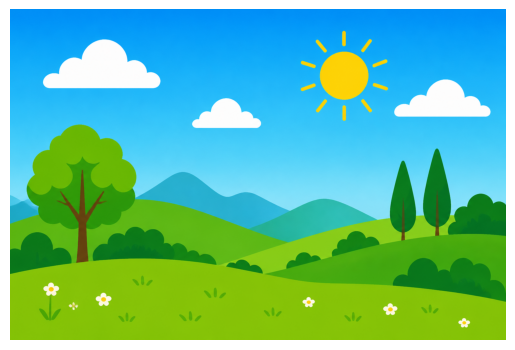

<class 'PIL.PngImagePlugin.PngImageFile'>
----------------------------------------------------------------------------------------------------
(1024, 1536, 3)
----------------------------------------------------------------------------------------------------


In [2]:
import torch                          # 导入 PyTorch 深度学习框架，提供张量（Tensor）计算和自动微分功能
from torchvision import transforms   # 导入 torchvision 的 transforms 模块，包含丰富的图像预处理与增强工具
from PIL import Image                # 导入 PIL（Pillow）库的 Image 模块，用于图像文件的读取、保存和基本操作
import matplotlib.pyplot as plt      # 导入 matplotlib 绘图库的 pyplot 子模块，用于可视化显示图像
import numpy as np                   # 导入 NumPy 数值计算库，用于多维数组操作和图像数据处理

# ── 加载图像 ──────────────────────────────────────────────────────────────────
# Image.open(fp) - 以懒加载方式打开指定路径的图像文件
#   参数 fp (str | Path): 图像文件路径，这里指向当前工作目录下的 'luke.jpg'
#   返回值 (PIL.Image.Image): PIL 图像对象，包含图像模式、尺寸及像素数据
img = Image.open('demo_image.png')

# ── 显示原始图像 ──────────────────────────────────────────────────────────────
# plt.imshow(X) - 将图像数据渲染到坐标轴上
#   参数 X: 可接受 PIL.Image 对象、numpy 数组（H×W×C 或 H×W）等
plt.imshow(img)
# plt.axis('off') - 关闭坐标轴的刻度、标签和边框，使图像显示更加简洁
plt.axis('off')
# plt.show() - 触发渲染并弹出图像显示窗口；在 Jupyter 中会将图像内嵌输出
plt.show()

# ── 打印图像元信息 ────────────────────────────────────────────────────────────
# type(img) - 返回 img 的 Python 类型对象，预期输出 <class 'PIL.JpegImagePlugin.JpegImageFile'>
print(type(img))
print('-' * 100)  # 打印 100 个连字符作为分隔线，便于区分不同输出段落

# np.array(object, dtype) - 将 PIL 图像对象转换为 NumPy 多维数组
#   参数 object: 需要转换的数据，这里传入 PIL 图像对象
#   参数 dtype (type): 指定数组元素的数据类型，np.float32 为 32 位浮点数
#     使用浮点数而非默认 uint8(0~255)，便于后续归一化和模型输入处理
#   返回值 (np.ndarray): 形状为 (H, W, C) 的三维数组
#     H = 图像高度（像素行数），W = 图像宽度（像素列数），C = 通道数（RGB 为 3）
img_array = np.array(img, dtype=np.float32)
# 打印图像数组的形状，例如 (512, 512, 3) 表示 512×512 的 RGB 彩色图像
print(img_array.shape)
print('-' * 100)  # 打印分隔线

## 二、图像维度预处理

In [2]:
# PyTorch 模型的输入要求是四维张量，维度含义依次为：
#   (batch_size, channels, height, width)
#   batch_size  - 一次送入模型的图片数量（批量大小）
#   channels    - 图像通道数，彩色图像为 3（R/G/B），灰度图为 1
#   height      - 图像高度（像素行数）
#   width       - 图像宽度（像素列数）
# 当前 img_array 形状为 (H, W, C)，需要在最前面增加一个 batch 维度

# np.expand_dims(a, axis) - 在指定轴位置插入一个长度为 1 的新维度
#   参数 a (np.ndarray): 输入数组，当前形状为 (H, W, C)
#   参数 axis (int): 要插入新维度的轴位置
#     axis=0 表示在第 0 个位置（最前面）插入，模拟 batch_size=1 的批量维度
#   返回值 (np.ndarray): 形状从 (H, W, C) 扩展为 (1, H, W, C)
#     注意：此方法不复制数据，返回的是原数组的视图（view）
img_array = np.expand_dims(img_array, axis=0)
# 打印扩展维度后的数组形状，预期输出如 (1, 512, 512, 3)，第一维为 batch 维度
print(img_array.shape)

(1, 533, 355, 3)


## 三、定义与应用图像增强变换流水线

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


torch.Size([3, 256, 256])


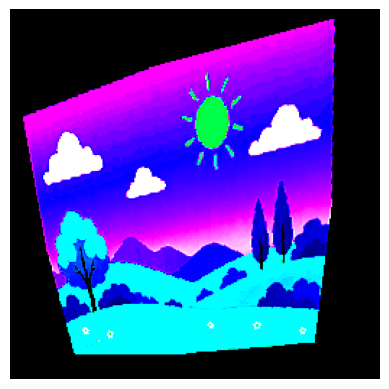

In [52]:
# ── 定义图像增强变换流水线 ────────────────────────────────────────────────────
# transforms.Compose(transforms) - 将多个图像变换操作串联成一个流水线，按列表顺序依次执行
#   参数 transforms (list): 包含各个 transform 操作对象的列表
#   返回值 (transforms.Compose): 一个可调用的组合变换对象，对图像依次应用每个变换
# ── 输入类型与 shape 要求 ────────────────────────────────────────────
#   输入类型：必须为 PIL.Image.Image 对象（不支持 numpy ndarray 或 torch.Tensor 直接输入）
#             如需从 ndarray 转换：Image.fromarray(arr.astype(np.uint8))
#   输入 shape（等效）：(H, W, C)
#     H（高度）：任意正整数，Resize 负责统一缩放，无最小限制
#     W（宽度）：任意正整数，同上
#     C（通道数）：必须为 3（RGB 三通道）
#               启用 Normalize 时 mean/std 均为 3 个元素，通道不匹配会报错
transform = transforms.Compose([

    # transforms.Resize(size) - 将输入图像缩放到指定的固定尺寸
    #   参数 size (int | tuple): 目标尺寸
    #     若为 int，则将短边缩放到该值，同时保持宽高比
    #     若为 (h, w) 元组，则直接缩放到指定的高度和宽度
    #   参数说明：(256, 256) 表示目标高度=256像素，目标宽度=256像素
    #   返回值：尺寸调整后的 PIL 图像
    transforms.Resize((256, 256)),  # 将图像统一缩放为 256×256 像素

    # transforms.RandomRotation(degrees) - 在指定角度范围内随机旋转图像
    #   参数 degrees (number | sequence): 旋转角度范围
    #     若为 number，则在 [-degrees, +degrees] 范围内均匀随机采样旋转角度
    #     若为 (min, max)，则在 [min, max] 范围内采样
    #   返回值：旋转后的 PIL 图像
    transforms.RandomRotation(45),  # 随机旋转，角度范围 [-45°, +45°]

    # transforms.RandomHorizontalFlip(p) - 以给定概率随机水平翻转图像
    #   参数 p (float): 执行水平翻转的概率，默认值为 0.5（即 50% 概率翻转）
    #   水平翻转 = 左右镜像，常用于增强模型对目标朝向的不变性
    #   返回值：水平翻转或原图的 PIL 图像
    transforms.RandomHorizontalFlip(p=0.5),  # 随机水平翻转（左右镜像），默认概率 0.5

    # transforms.RandomVerticalFlip(p) - 以给定概率随机垂直翻转图像
    #   参数 p (float): 执行垂直翻转的概率，p=1.0 表示必定翻转
    #   垂直翻转 = 上下镜像，适用于遥感、显微镜图像等无方向限制的场景
    #   返回值：垂直翻转或原图的 PIL 图像
    transforms.RandomVerticalFlip(p=0.5),  # 随机垂直翻转（上下镜像），概率 0.5

    # transforms.ColorJitter(brightness, contrast, saturation, hue) - 随机调整图像颜色属性
    #   参数 brightness (float | tuple): 亮度调整因子，取值范围为 [max(0, 1-x), 1+x]
    #   参数 contrast (float | tuple): 对比度调整因子，取值范围同 brightness
    #   参数 saturation (float | tuple): 饱和度调整因子，取值范围同 brightness
    #   参数 hue (float | tuple): 色调偏移范围，须在 [0, 0.5] 内，正负方向均会调整
    #   返回值：颜色属性随机调整后的 PIL 图像
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5),

    # transforms.RandomCrop(size) - 从图像中随机位置裁剪出指定大小的矩形区域（已注释）
    #   参数 size (int | tuple): 裁剪区域的尺寸，(224, 224) 表示裁剪 224×224 像素
    #   注意：输入图像须大于等于裁剪尺寸，否则会报错
    #   返回值：裁剪后的 PIL 图像
    # transforms.RandomCrop((224, 224)),  # 从随机位置裁剪出 224×224 的区域

    # transforms.RandomGrayscale(p) - 以给定概率将图像转换为灰度图（已注释）
    #   参数 p (float): 转换为灰度的概率，p=0.7 表示 70% 的概率转为灰度
    #   注意：即使转为灰度，输出仍保持原图的通道数（RGB → 三通道灰度图）
    #   返回值：灰度化或原图的 PIL 图像
    # transforms.RandomGrayscale(p=0.7),  # 随机灰度化，概率 0.7

    # ── 随机透视变换 ──────────────────────────────────────────────────────────
    # transforms.RandomPerspective(distortion_scale, p) - 以给定概率对图像应用随机透视变换
    #   透视变换通过改变四个角点的位置模拟从不同角度拍摄同一物体的效果
    #   参数 distortion_scale (float): 畸变程度，取值范围 [0, 1]
    #     值越接近 0，变形越轻微；值越接近 1，变形越剧烈
    #   参数 p (float): 应用该变换的概率，p=0.5 表示 50% 概率执行透视变换
    #   返回值：透视变换后或原图的 PIL 图像
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5),  # 随机透视变换，畸变强度0.5，应用概率0.5

    # transforms.RandomInvert(p) - 以给定概率随机反转图像所有通道的像素值（已注释）
    #   像素反转公式：output = 255 - input（针对 uint8 图像）
    #   参数 p (float): 执行颜色反转的概率
    #   返回值：颜色反转或原图的 PIL 图像
    # transforms.RandomInvert(p=0.5),  # 随机颜色反转（取补色）

    # transforms.RandomAdjustSharpness(sharpness_factor, p) - 随机调整图像锐度（已注释）
    #   参数 sharpness_factor (float): 锐度因子
    #     0   = 完全模糊（纯模糊滤波结果）
    #     1   = 原始图像（不做任何调整）
    #     >1  = 锐化增强（增强边缘细节）
    #   参数 p (float): 应用锐度调整的概率
    #   返回值：锐度调整后或原图的 PIL 图像
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5),  # 随机锐化，锐度系数2，概率0.5

    # transforms.RandomAutocontrast(p) - 随机对图像执行自动对比度拉伸（已注释）
    #   自动对比度将图像最暗像素拉伸至 0，最亮像素拉伸至 255，增强对比度
    #   参数 p (float): 应用自动对比度的概率
    #   返回值：对比度拉伸后或原图的 PIL 图像
    transforms.RandomAutocontrast(p=0.5),  # 随机自动对比度，概率0.5

    # transforms.ToTensor() - 将 PIL 图像转换为 PyTorch 浮点张量
    #   执行以下两个关键操作：
    #   1. 维度重排：(H, W, C) → (C, H, W)（PyTorch 约定通道维在前）
    #   2. 像素归一化：将像素值从 [0, 255]（uint8）映射到 [0.0, 1.0]（float32）
    #   返回值 (torch.Tensor): 形状为 (C, H, W)，dtype 为 torch.float32 的张量
    transforms.ToTensor(),  # 将 PIL 图像转为张量，并将像素值归一化至 [0.0, 1.0]

    # transforms.Normalize(mean, std) - 对各通道张量进行 Z-Score 标准化（已注释）
    #   标准化公式（逐通道）：output[c] = (input[c] - mean[c]) / std[c]
    #   参数 mean (list[float]): 各通道的均值，[0.485, 0.456, 0.406] 为 ImageNet 数据集 RGB 均值
    #   参数 std (list[float]): 各通道的标准差，[0.229, 0.224, 0.225] 为 ImageNet 数据集 RGB 标准差
    #   使用 ImageNet 统计值可加速迁移学习中预训练模型的收敛
    #   返回值 (torch.Tensor): 标准化后的张量
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ── 对原始图像应用变换流水线 ───────────────────────────────────────────────────
# transform(img) - 对 PIL 图像依次执行 Compose 中定义的所有变换
#   参数 img (PIL.Image.Image): 原始 PIL 图像对象
#   返回值 img_t (torch.Tensor): 形状为 (C, H, W) 的 PyTorch 张量
#     C=3（RGB 三通道），H=256，W=256（经过 Resize 处理后）
img_t = transform(img)

# 打印转换后图像张量的形状，预期输出 torch.Size([3, 256, 256])
print(img_t.shape)

# np.transpose(a, axes) - 按指定轴顺序重新排列数组的维度
#   参数 a: 输入数组，img_t 是 (C, H, W) 格式的 PyTorch 张量（需先转为 numpy）
#   参数 axes (tuple): 新的维度排列顺序
#     (1, 2, 0) 将维度从 (C, H, W) 转为 (H, W, C)，符合 matplotlib 的显示格式要求
plt.imshow(np.transpose(img_t, (1, 2, 0)))  # 将张量维度从 (C,H,W) 转为 (H,W,C) 后显示
plt.axis('off')   # 关闭坐标轴刻度和边框
plt.show()        # 渲染并显示增强后的图像

## 四、图像保存

In [53]:

# plt.imsave(fname, arr) - 将数组以图像格式保存到磁盘
#   参数 fname (str): 保存路径和文件名，图像格式由扩展名自动推断（如 .png）
#   参数 arr (np.ndarray): 形状为 (H, W, C) 的图像数组，像素值范围 [0.0, 1.0] 或 [0, 255]
# plt.imsave('luke_aug.png', np.transpose(img_t, (1, 2, 0)))

## 五、备用图像加载方式（参考）

In [2]:
# ── 备用图像加载方式（已注释，供参考对比） ────────────────────────────────────
# 以下代码展示了加载图像时显式指定颜色模式为 RGB 的方式
# 适用于来源不确定的图像（可能包含 RGBA、L 等非标准模式）

# Image.open(fp).convert(mode) - 打开图像文件并立即转换其颜色模式
#   Image.open(fp):
#     参数 fp (str | Path): 图像文件路径，'luke.jpg' 为当前目录下的文件
#     返回值: PIL.Image.Image 对象（此时可能是任意颜色模式）
#   .convert(mode):
#     参数 mode (str): 目标颜色模式
#       'RGB'  - 三通道彩色模式（红、绿、蓝），每通道 0~255
#       'RGBA' - 四通道模式（含透明通道 Alpha）
#       'L'    - 灰度模式（单通道，0~255）
#     返回值: 转换后的 PIL.Image.Image 对象，确保图像为三通道 RGB 格式
#   使用 .convert('RGB') 的好处：统一图像格式，避免 JPEG/PNG 格式差异导致通道数不匹配
# img = Image.open('luke.jpg').convert('RGB')

# np.array(img, dtype=np.float32) - 将 PIL 图像转为 float32 类型的 NumPy 数组
#   参数 img (PIL.Image.Image): 已加载的 RGB 图像对象
#   参数 dtype (type): 数据类型，np.float32 为 32 位浮点数
#   返回值 (np.ndarray): 形状为 (H, W, 3) 的三维数组，像素值范围 [0.0, 255.0]
# img_array = np.array(img, dtype=np.float32)

# print(img_array.shape) - 打印数组的形状元组，预期输出如 (512, 512, 3)
# print(img_array.shape)

(533, 355, 3)


## 六、图像增强的意义与总结

In [ ]:
# ── 图像增强（Data Augmentation）的核心价值总结 ──────────────────────────────
#
# 图像增强是深度学习图像任务中的关键预处理手段，主要通过对原始训练图像
# 施加各种随机变换（翻转、旋转、裁剪、颜色抖动、透视变换等）来扩充训练数据。
#
# 主要作用：
#   1. 提升泛化能力：让模型学到更多样化的特征表示，减少对特定训练样本的记忆
#   2. 增强鲁棒性：模型能够适应现实场景中的各种图像变化条件（光照、角度、遮挡）
#   3. 提升适应性：无需额外采集数据即可有效扩大训练集规模，降低数据收集成本
#   4. 缓解过拟合：正则化效果显著，特别适合小样本数据集的训练场景
#
# 增加了模型的泛化能力，提升了模型的鲁棒性和适应性。